# Semana 12 - Practicar Matplotlib

**Propósito:** aplicar `pandas` y `matplotlib` para explorar, graficar e interpretar datos reales de nacimientos y defunciones.

Este notebook está dividido en tres niveles:

- **Nivel básico:** cargar, revisar y limpiar datos.
- **Nivel intermedio:** crear gráficos correctos y explicar lo observado.
- **Reto final:** diseñar un gráfico propio para responder una pregunta.


## Criterios de logro

Al completar la práctica, su entrega debe demostrar que puede:

- Cargar un CSV y revisar su estructura.
- Seleccionar, filtrar y crear columnas nuevas.
- Crear gráficos con título, etiquetas, leyenda y tamaño adecuado.
- Interpretar los gráficos con frases claras.
- Justificar qué tipo de gráfico eligió.


## Nivel básico - 1. Preparación

Ejecute esta celda para cargar las bibliotecas y el archivo de datos.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("nacimientos_defunciones.csv")
df.head()



,Año,Nacimientos,Defunciones
0,1950,37248,9769
1,1951,39239,9631
2,1952,42461,9902
3,1953,42817,10312
4,1954,48157,9713


## Nivel básico - 2. Exploración inicial

Complete las instrucciones. La meta es conocer el DataFrame antes de graficar.


In [3]:
# TODO: muestre la cantidad de filas y columnas con df.shape
print("Shape del data Frame:", df.shape)
# TODO: muestre los nombres de las columnas con df.columns
print("Nombres de las columnas:", list( df.columns))
# TODO: muestre los tipos de datos con df.dtypes
print("Tipos de datos de las columnas:", df.dtypes)
# TODO: muestre un resumen estadístico con df.describe()
print("Resumen estadístico del data Frame:\n", df.describe())   

Shape del data Frame: (72, 3)
Nombres de las columnas: ['Año', 'Nacimientos', 'Defunciones']
Tipos de datos de las columnas: Año            int64
Nacimientos    int64
Defunciones    int64
dtype: object
Resumen estadístico del data Frame:
               Año   Nacimientos   Defunciones
count    72.00000     72.000000     72.000000
mean   1985.50000  67308.430556  13548.625000
std      20.92845  11303.292169   4872.104426
min    1950.00000  37248.000000   8596.000000
25%    1967.75000  58944.750000   9899.750000
50%    1985.50000  69996.500000  11377.500000
75%    2003.25000  75490.500000  15837.250000
max    2021.00000  84337.000000  31093.000000


**Pregunta de interpretación:** ¿qué años cubre el archivo y cuántos registros tiene?


## Nivel básico - 3. Limpieza básica

Antes de analizar, confirme si hay valores nulos.


In [ ]:
# TODO: muestre cuántos valores nulos hay por columna
print("Valores nulos por columna:\n", df.isnull().sum())
# TODO: elimine filas con valores nulos, si existieran
df.dropna(inplace=True)
# TODO: vuelva a revisar los valores nulos
print("Valores nulos por columna después de eliminar filas con valores nulos:\n", df.isnull().sum())

**Pista:** puede usar `df.isna().sum()` y `df.dropna(inplace=True)`.


## Nivel básico - 4. Selección de columnas

Cree un DataFrame solo con `Año` y `Nacimientos`.


In [ ]:
# TODO: cree un DataFrame llamado df_nacimientos con las columnas Año y Nacimientos
df_nacimientos = df[["Año", "Nacimientos"]].copy()


# TODO: muestre las primeras 5 filas
df_nacimientos.head()

**Pregunta de interpretación:** ¿por qué conviene crear DataFrames más pequeños para ciertos análisis?


## Nivel básico - 5. Filtrado de datos

Cree un DataFrame con datos desde 2010 en adelante.


In [5]:
# TODO: cree un DataFrame llamado df_2010 con datos desde el año 2010
#df_2010 = df_nacimientos[df_nacimientos["Año"] >= 2010].copy()
seleccion = df["Año"] >= 2010
df_2010 = df[seleccion].copy()

# TODO: muestre los datos filtrados
df_2010

,Año,Nacimientos,Defunciones
60,2010,70922,19077
61,2011,73459,18801
62,2012,73326,19200
63,2013,70550,19646
64,2014,71793,20560
65,2015,71819,21038
66,2016,70004,22601
67,2017,68811,23246
68,2018,68449,23806
69,2019,64274,24292


**Pista:** use una condición como `df["Año"] >= 2010`.


## Nivel intermedio - 6. Cálculos básicos

Calcule totales y agregue una columna nueva.


In [8]:

# TODO: calcule el total de nacimientos
# total_nacimientos = ...
total_nacimientos = df["Nacimientos"].sum()
# TODO: calcule el total de defunciones
# total_defunciones = ...
total_defunciones = df["Defunciones"].sum()
# TODO: cree la columna Saldo Poblacional
# df["Saldo Poblacional"] = ...
df["Saldo_Poblacional"] = df["Nacimientos"] - df["Defunciones"]
df.head()
# TODO: muestre total_nacimientos, total_defunciones y df.head()
print("Total de nacimientos:", total_nacimientos)
print("Total de defunciones:", total_defunciones)
print("Saldo Poblacional:\n", df["Saldo_Poblacional"].sum())

Total de nacimientos: 4846207
Total de defunciones: 975501
Saldo Poblacional:
 3870706


**Pregunta de interpretación:** ¿qué significa el saldo poblacional en este conjunto de datos?


## Nivel intermedio - 7. Gráfico de líneas: nacimientos por año

Cree un gráfico de líneas con `Año` en el eje X y `Nacimientos` en el eje Y.


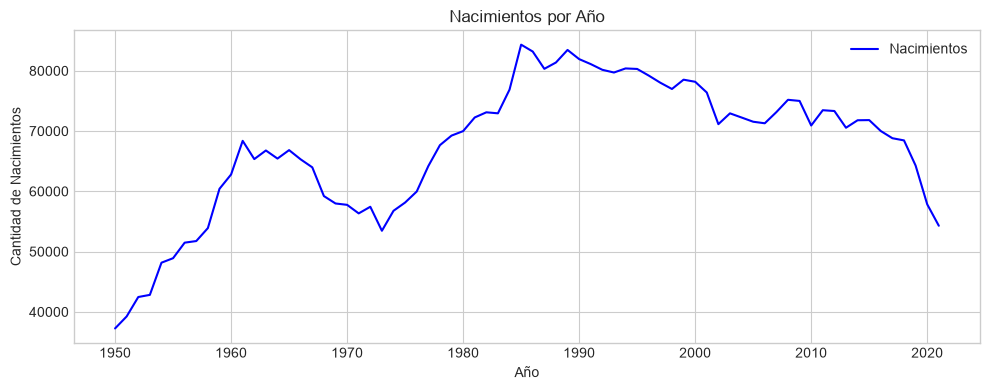

In [10]:
# TODO: cree una figura con figsize=(10, 4)
plt.figure(figsize=(10, 4))
# TODO: grafique Año vs Nacimientos
plt.plot(df["Año"], df["Nacimientos"], label="Nacimientos", color="blue")
# TODO: agregue título, etiqueta X, etiqueta Y y plt.tight_layout()
plt.title("Nacimientos por Año")
plt.xlabel("Año")
plt.ylabel("Cantidad de Nacimientos")
plt.tight_layout() 
plt.legend()
plt.show()
# TODO: muestre el gráfico con plt.show()


**Pregunta de interpretación:** ¿los nacimientos muestran una tendencia general de aumento, disminución o estabilidad?


## Nivel intermedio - 8. Comparación de nacimientos y defunciones

Cree un gráfico con dos líneas y una leyenda.


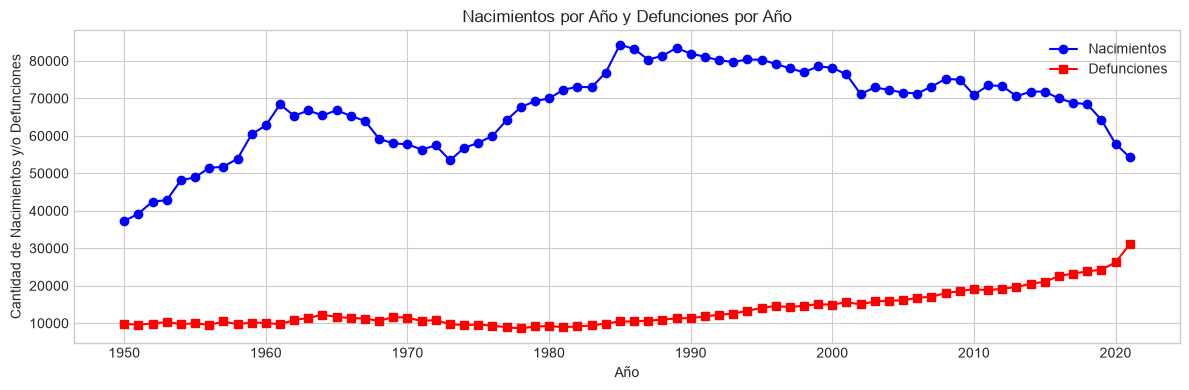

In [13]:
# TODO: cree fig, ax = plt.subplots(figsize=(10, 4))
# TODO: grafique Nacimientos y Defunciones contra Año
# TODO: use colores distintos y label en cada línea
# TODO: agregue título, etiquetas y leyenda
# TODO: aplique plt.tight_layout() y plt.show()
plt.figure(figsize=(12, 4))
plt.plot(df["Año"], df["Nacimientos"], label="Nacimientos", color="blue", marker="o")
plt.plot(df["Año"], df["Defunciones"], label="Defunciones", color="red", marker="s")
plt.title("Nacimientos por Año y Defunciones por Año")
plt.xlabel("Año")
plt.ylabel("Cantidad de Nacimientos y/o Defunciones")
plt.tight_layout() 
plt.legend()
plt.show()

**Pregunta de interpretación:** ¿en qué parte del periodo la distancia entre nacimientos y defunciones parece mayor?


## Nivel intermedio - 9. Gráfico de barras del último año

Compare nacimientos y defunciones en el último año disponible.


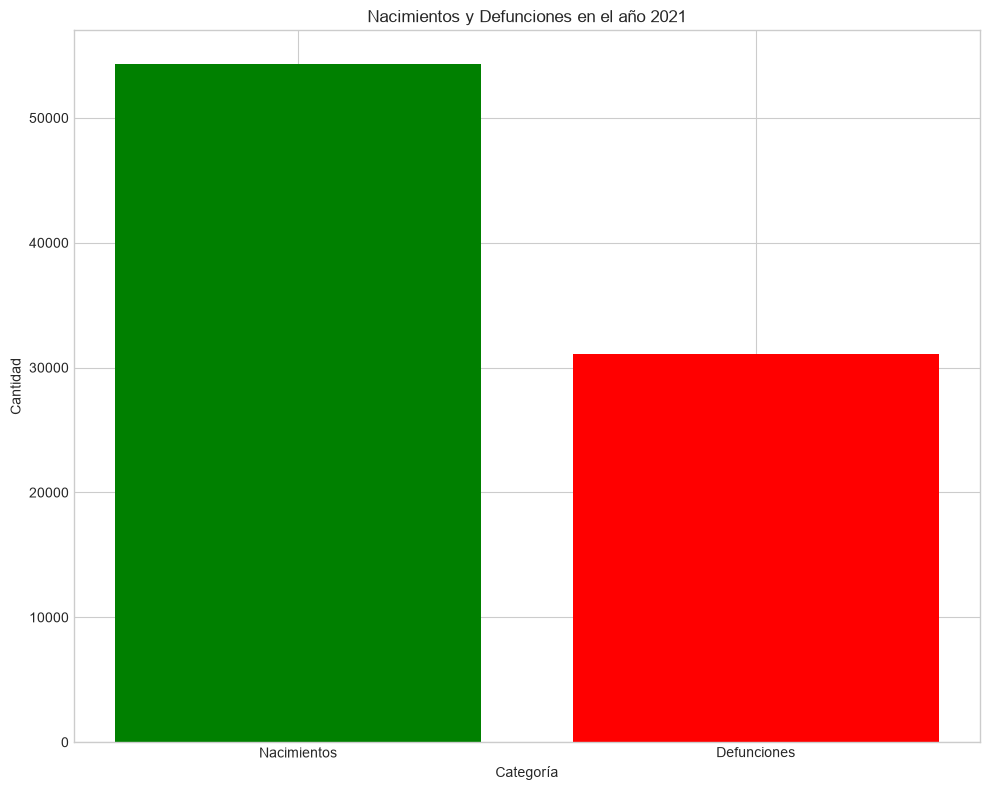

In [16]:
# TODO: obtenga el último año disponible con df["Año"].max()
ultimo_anio = df["Año"].max()

# TODO: filtre la fila del último año
datos_ultimo_anio = df[df["Año"] == ultimo_anio]

# TODO: cree listas para categorias y valores
categorias = ["Nacimientos", "Defunciones"]
valores = [datos_ultimo_anio["Nacimientos"].values[0], datos_ultimo_anio["Defunciones"].values[0]]

# TODO: cree un gráfico de barras con título y etiquetas

plt.figure(figsize=(10, 8))
plt.bar(categorias, valores, color=["green", "red"])
plt.title(f"Nacimientos y Defunciones en el año {ultimo_anio}")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()  

**Pregunta de interpretación:** ¿qué diferencia observa entre nacimientos y defunciones en el último año?


## Nivel intermedio - 10. Saldo poblacional desde 2010

Use los datos filtrados desde 2010 y grafique el saldo poblacional.


In [ ]:
# TODO: asegúrese de que df_2010 tenga una copia de los datos filtrados
# df_2010 = df[df["Año"] >= 2010].copy()

# TODO: cree la columna Saldo Poblacional en df_2010

# TODO: grafique Año vs Saldo Poblacional


**Pregunta de interpretación:** ¿el saldo poblacional desde 2010 sube, baja o se mantiene? Explique con base en el gráfico.


## Nivel intermedio - 11. Subgráficos

Cree una figura con dos subgráficos:

1. Nacimientos y defunciones por año.
2. Saldo poblacional por año.


In [ ]:
# TODO: cree fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# TODO: en axes[0], grafique nacimientos y defunciones por año

# TODO: en axes[1], grafique saldo poblacional por año

# TODO: agregue títulos, etiquetas y leyendas cuando corresponda

# TODO: use plt.tight_layout() y plt.show()


**Pregunta de interpretación:** ¿qué ventaja tiene ver ambos gráficos en una misma figura?


## Buenas prácticas antes del reto final

Revise que sus gráficos cumplan con estas reglas:

- El título explica el contenido del gráfico.
- Los ejes tienen nombres claros.
- La leyenda aparece cuando hay más de una serie.
- Los colores tienen un propósito.
- El gráfico responde una pregunta concreta.


## Reto final - 12. Pregunta propia

Construya un gráfico propio que responda una pregunta sobre los datos.

Ejemplos:

- ¿Cuáles son los 10 años con más nacimientos?
- ¿Cómo cambió el saldo poblacional en las últimas dos décadas?
- ¿Las defunciones aumentan o disminuyen con el tiempo?
- ¿Qué diferencia hay entre el primer y el último año del registro?


**Pregunta elegida:** escriba aquí la pregunta que desea responder.


In [ ]:
# TODO: cree el gráfico final
# Requisitos: título, etiquetas, tamaño adecuado e interpretación escrita debajo


**Interpretación final:** escriba 3 o 4 frases explicando qué muestra su gráfico y qué conclusión obtiene.


## Rúbrica breve

Use esta rúbrica para revisar su entrega:

| Criterio | Logrado | Pendiente |
|---|---|---|
| El notebook ejecuta sin errores |  |  |
| El CSV se carga correctamente |  |  |
| Se crean columnas y filtros solicitados |  |  |
| Los gráficos tienen título y etiquetas |  |  |
| Las interpretaciones responden las preguntas |  |  |
| El reto final tiene una pregunta clara |  |  |


## Cierre metacognitivo

Responda:

1. ¿Qué gráfico le ayudó más a entender los datos?
2. ¿Qué decisión visual cambió más la lectura del gráfico?
3. ¿Qué parte de Matplotlib necesita seguir practicando?
